# JobPulseKE - NLP Analysis 

This notebook runs the NLP stage (skill extraction, metadata extraction, classification, topic modelling) on the current cleaned dataset, and analyzes candidate CVs.


## 1. Setup

In [21]:
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path().resolve().parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.nlp.nlp_analysis_pipeline import NLPAnalysisPipeline
from src.nlp.category_classifier import TechCategoryClassifier, DEFAULT_PARAM_GRID
from src.config import ANALYZED_CV_DIR

pd.set_option("display.max_colwidth", 120)
plt.rcParams["figure.facecolor"] = "white"

# Everything below is a method call on this one object.
pipeline = NLPAnalysisPipeline()

## 2. Load data

In [22]:
df = pipeline.load_data()

print(f"Rows: {len(df):,}   Columns: {len(df.columns)}")
df.head(3)

Rows: 10,379   Columns: 26


,job_id,source,source_job_id,job_title,company,job_description,location,country,work_mode,remote_scope,...,currency,date_posted,application_deadline,tech_category,vacancy_url,scraped_at,has_real_description,title_clean,desc_clean,text_for_nlp
0,bbd20f21c744b6fb,brightermonday,office-admin-pgdzvv,OFFICE ADMIN,None,OFFICE ADMIN,None,Kenya,unknown,None,...,None,None,NaN,None,https://www.brightermonday.co.ke/listings/office-admin-pgdzvv,2026-08-30T15:41:00+00:00,False,OFFICE ADMIN,,OFFICE ADMIN
1,e7b1c86afa914d37,brightermonday,lead-baker-5p6jmp,LEAD BAKER,None,LEAD BAKER,None,Kenya,unknown,None,...,None,None,NaN,None,https://www.brightermonday.co.ke/listings/lead-baker-5p6jmp,2026-08-30T15:41:00+00:00,False,LEAD BAKER,,LEAD BAKER
2,8c65dfc4609af714,brightermonday,sales-marketing-qz4jm6,Sales & Marketing,None,Sales & Marketing,None,Kenya,unknown,None,...,None,None,NaN,None,https://www.brightermonday.co.ke/listings/sales-marketing-qz4jm6,2026-08-30T15:41:00+00:00,False,Sales & Marketing,,Sales & Marketing


## 3. Data quality report

In [23]:
report = pipeline.run_data_quality_report()

print(f"Rows with a REAL description: {report['n_real']:,} / {report['n_total']:,} ({report['overall_pct_real']:.1f}%)")
report["coverage_by_source"]

Rows with a REAL description: 1,118 / 10,379 (10.8%)


,total,real,pct_real
source,,,
fantastic_jobs_hf,5374,0,0.0
jobberman,1939,0,0.0
linkedin,1147,0,0.0
hotnigerianjobs,813,813,100.0
myjobmag,654,0,0.0
indeed,110,0,0.0
fuzu,90,89,98.9
brightermonday,74,47,63.5
jobicy,71,71,100.0


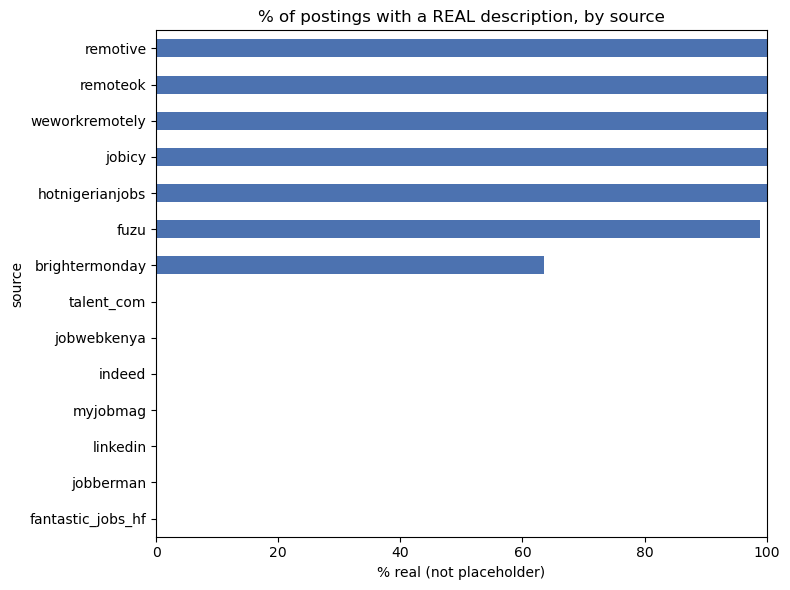

In [24]:
report["coverage_by_source"]["pct_real"].sort_values().plot(kind="barh", figsize=(8, 6), color="#4C72B0")
plt.title("% of postings with a REAL description, by source")
plt.xlabel("% real (not placeholder)")
plt.xlim(0, 100)
plt.tight_layout()
plt.show()

### tech_category label quality

`NLPAnalysisPipeline.load_data()` already applied the category normalization (`Cloud & DevOps` → `DevOps & Cloud`, `Product & UX` → `Product & Design`) - kept as a single constant (`CATEGORY_NORMALIZATION` in `category_classifier.py`) so training and serving can never drift apart.

In [25]:
print("tech_category value counts (already normalized):")
df["tech_category"].value_counts(dropna=False)

tech_category value counts (already normalized):


tech_category
Other Tech                 3974
None                       2432
Software Development       1685
Data & AI                  1036
Software & IT               379
IT Support & Networking     196
QA & Testing                190
Product & Design            186
Cybersecurity               144
DevOps & Cloud              142
Networking                   15
Name: count, dtype: int64

## 4. Text cleaning

`title_clean` / `desc_clean` / `text_for_nlp` are built automatically inside `load_data()` - placeholder descriptions are excluded from `desc_clean` so they can't silently pollute downstream extraction.

In [26]:
df.loc[df["has_real_description"], ["job_title", "desc_clean"]].sample(2, random_state=1)

,job_title,desc_clean
5706,Managed Services NOC Supervisor at Equinix Nigeria,Equinix Nigeria is recruiting to fill the position of: Managed Services NOC Supervisor. The position is located in L...
9581,Lead UX Designer | EMEA | Contract,"Location: Remote — EMEA (Open to applicants in Europe, the Middle East and Africa) Fueled is a leading digital strat..."


## 5. Skill extraction

In [27]:
top_skills = pipeline.extract_skills()

for label, subset in [("Real-description rows", df[df["has_real_description"]]),
                       ("Title-only rows", df[~df["has_real_description"]])]:
    pct_matched = (subset["n_skills_found"] > 0).mean() * 100
    print(f"{label}: {len(subset):,} rows, {pct_matched:.1f}% matched at least one skill")

Real-description rows: 1,118 rows, 17.6% matched at least one skill
Title-only rows: 9,261 rows, 5.6% matched at least one skill


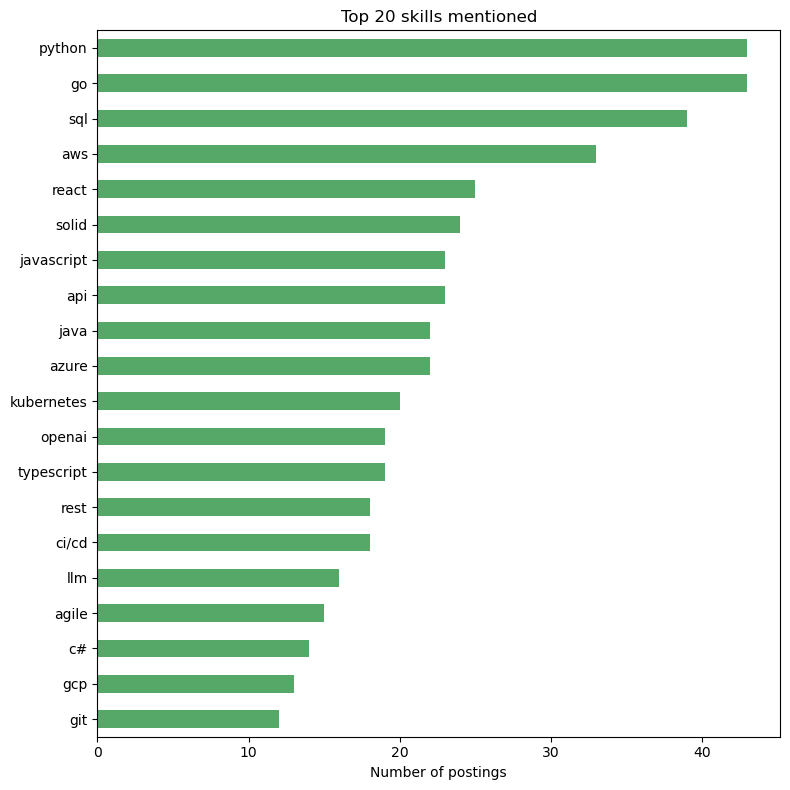

python        43
go            43
sql           39
aws           33
react         25
solid         24
javascript    23
api           23
java          22
azure         22
kubernetes    20
openai        19
typescript    19
rest          18
ci/cd         18
llm           16
agile         15
c#            14
gcp           13
git           12
dtype: int64

In [28]:
top_skills.head(20).plot(kind="barh", figsize=(8, 8), color="#55A868")
plt.title(f"Top 20 skills mentioned")
plt.xlabel("Number of postings")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

top_skills.head(20)

In [29]:
# Skills by tech_category, real-description rows only
real_df = df[df["has_real_description"]].copy()
exploded = real_df.explode("skills_found").dropna(subset=["skills_found"])
skill_by_cat = exploded.groupby(["tech_category", "skills_found"]).size().reset_index(name="count")

for cat in real_df["tech_category"].dropna().unique():
    top = skill_by_cat[skill_by_cat["tech_category"] == cat].sort_values("count", ascending=False).head(5)
    if top.empty:
        continue
    print(f"\n{cat}:")
    print(top[["skills_found", "count"]].to_string(index=False))


Software Development:
skills_found  count
      python     19
          go     16
        java     16
       react     15
         aws     14

Other Tech:
       skills_found  count
              scrum      3
                aws      3
              excel      3
amazon web services      3
              agile      2

Cybersecurity:
skills_found  count
         aws      1
       azure      1
         gcp      1
          go      1
google cloud      1

DevOps & Cloud:
skills_found  count
         aws      4
  kubernetes      3
       ci/cd      2
         sql      2
       solid      2

Data & AI:
skills_found  count
      python     12
         sql      6
          go      5
       azure      5
         llm      5

Product & Design:
skills_found  count
          go      5
         sql      4
           r      2
       solid      2
       azure      1

QA & Testing:
skills_found  count
       ci/cd      1

Software & IT:
skills_found  count
         sql     14
          go     11
       

## 6. Metadata extraction

In [30]:
metadata = pipeline.extract_metadata()

print("Employment type (only reports what it actually detects):")
print(df["employment_type"].value_counts(dropna=False))
print(f"\nWork mode (only reports what it actually detects):")
print(df["work_mode"].value_counts(dropna=False))

Employment type (only reports what it actually detects):
employment_type
None          9957
Freelance      120
Full-Time       96
Contract        87
Internship      56
Part-Time       34
Temporary       29
Name: count, dtype: int64

Work mode (only reports what it actually detects):
work_mode
None       9731
Remote      517
Hybrid       78
On-Site      53
Name: count, dtype: int64


In [31]:
print(f"Rows with an EXPLICIT seniority keyword: {df['seniority_keyword_found'].sum():,} / {len(df):,} "
      f"({df['seniority_keyword_found'].mean()*100:.1f}%)")
print()
print(df["seniority_level"].value_counts())

Rows with an EXPLICIT seniority keyword: 3,778 / 10,379 (36.4%)

seniority_level
Unspecified    6601
Lead           1383
Senior         1163
Executive       365
Intern          358
Entry Level     339
Mid-Level       170
Name: count, dtype: int64


## 7. Years of experience, education, certifications

In [32]:
from collections import Counter

exp_df = pipeline.extract_experience_education()  # real-description rows only

has_exp = exp_df[exp_df["years_experience"] > 0]
print(f"Rows stating years of experience: {len(has_exp)} / {len(exp_df)} ({len(has_exp)/len(exp_df)*100:.1f}%)")
if len(has_exp) > 0:
    print(has_exp["years_experience"].describe())

edu_counts = Counter(e for edu_list in exp_df["education_required"] for e in edu_list)
print("\nEducation requirements mentioned:", dict(edu_counts))

cert_counts = Counter(c for cert_list in exp_df["certifications"] for c in cert_list)
print("Certifications mentioned:", dict(cert_counts))

Rows stating years of experience: 204 / 1118 (18.2%)
count    204.000000
mean       4.676471
std        2.632356
min        1.000000
25%        3.000000
50%        5.000000
75%        5.000000
max       18.000000
Name: years_experience, dtype: float64

Education requirements mentioned: {'Associate Degree': 545, 'Diploma/High School': 113, "Bachelor's Degree": 214, "Master's Degree": 273, 'PhD': 2}
Certifications mentioned: {'PMP': 3, 'AWS Certification': 44, 'Scrum Master': 3, 'Kubernetes Certification': 20, 'Azure Certification': 22, 'GCP Certification': 13, 'CISSP': 2}


## 8. Classification: predicting `tech_category` from text - tuned, class-based, backend-ready

The classifier used to be built inline in this notebook (a plain `TfidfVectorizer` + `LogisticRegression`, trained once with hardcoded parameters). It now lives in `TechCategoryClassifier` (`src/nlp/category_classifier.py`):

- `prepare_dataset()` filters to real-description rows and drops categories with too few rows to evaluate honestly.
- `tune()` runs `GridSearchCV` over the pipeline below to find the best hyperparameters.
- `evaluate()` reports held-out accuracy/F1/classification-report.
- `save()` / `load()` persist the *entire fitted pipeline* as one artifact - this is what `src/api/recommender_api.py`'s `/analyze-cv` endpoint loads at startup instead of retraining per request.

In [33]:
print("Hyperparameter search space:")
for k, v in DEFAULT_PARAM_GRID.items():
    print(f"  {k}: {v}")

# prepare_dataset() + tune() + evaluate(), all in one call
tuning_summary = pipeline.train_classifier(tune=True, param_grid=DEFAULT_PARAM_GRID, cv=5)

print(f"\nTrain rows: {tuning_summary['n_train']}   Test rows: {tuning_summary['n_test']}")
print(f"Best params: {tuning_summary['best_params']}")
print(f"Best CV {tuning_summary['scoring']}: {tuning_summary['best_score']:.3f}")
print(f"\nHeld-out test accuracy: {tuning_summary['evaluation']['accuracy']:.3f}")
print(f"Held-out test F1 (macro): {tuning_summary['evaluation']['f1_macro']:.3f}")

Hyperparameter search space:
  tfidf__max_features: [1500, 3000, 5000]
  tfidf__ngram_range: [(1, 1), (1, 2)]
  tfidf__min_df: [1, 2]
  clf__C: [0.1, 1.0, 5.0, 10.0]

Train rows: 489   Test rows: 163
Best params: {'clf__C': 1.0, 'tfidf__max_features': 5000, 'tfidf__min_df': 2, 'tfidf__ngram_range': (1, 1)}
Best CV f1_macro: 0.604

Held-out test accuracy: 0.767
Held-out test F1 (macro): 0.673


### Top hyperparameter combinations tried

In [34]:
cv_results = pipeline.classifier.cv_results_.sort_values("rank_test_score")
cv_results[["params", "mean_test_score", "std_test_score", "rank_test_score"]].head(10)

,params,mean_test_score,std_test_score,rank_test_score
22,"{'clf__C': 1.0, 'tfidf__max_features': 5000, 'tfidf__min_df': 2, 'tfidf__ngram_range': (1, 1)}",0.604111,0.107253,1
18,"{'clf__C': 1.0, 'tfidf__max_features': 3000, 'tfidf__min_df': 2, 'tfidf__ngram_range': (1, 1)}",0.602195,0.103505,2
16,"{'clf__C': 1.0, 'tfidf__max_features': 3000, 'tfidf__min_df': 1, 'tfidf__ngram_range': (1, 1)}",0.599876,0.094348,3
28,"{'clf__C': 5.0, 'tfidf__max_features': 3000, 'tfidf__min_df': 1, 'tfidf__ngram_range': (1, 1)}",0.598523,0.117469,4
30,"{'clf__C': 5.0, 'tfidf__max_features': 3000, 'tfidf__min_df': 2, 'tfidf__ngram_range': (1, 1)}",0.589638,0.114910,5
40,"{'clf__C': 10.0, 'tfidf__max_features': 3000, 'tfidf__min_df': 1, 'tfidf__ngram_range': (1, 1)}",0.588044,0.131661,6
24,"{'clf__C': 5.0, 'tfidf__max_features': 1500, 'tfidf__min_df': 1, 'tfidf__ngram_range': (1, 1)}",0.585223,0.113786,7
38,"{'clf__C': 10.0, 'tfidf__max_features': 1500, 'tfidf__min_df': 2, 'tfidf__ngram_range': (1, 1)}",0.582465,0.104505,8
41,"{'clf__C': 10.0, 'tfidf__max_features': 3000, 'tfidf__min_df': 1, 'tfidf__ngram_range': (1, 2)}",0.580813,0.101660,9
36,"{'clf__C': 10.0, 'tfidf__max_features': 1500, 'tfidf__min_df': 1, 'tfidf__ngram_range': (1, 1)}",0.580377,0.097960,10


### Classification report (held-out test set)

In [35]:
import json

print(json.dumps(tuning_summary["evaluation"]["report"], indent=2))

{
  "Cybersecurity": {
    "precision": 1.0,
    "recall": 0.5,
    "f1-score": 0.6666666666666666,
    "support": 4
  },
  "Data & AI": {
    "precision": 0.34782608695652173,
    "recall": 0.47058823529411764,
    "f1-score": 0.39999999999999997,
    "support": 17
  },
  "DevOps & Cloud": {
    "precision": 0.5,
    "recall": 0.5,
    "f1-score": 0.5,
    "support": 4
  },
  "IT Support & Networking": {
    "precision": 0.5,
    "recall": 1.0,
    "f1-score": 0.6666666666666666,
    "support": 4
  },
  "Other Tech": {
    "precision": 0.8958333333333334,
    "recall": 0.8269230769230769,
    "f1-score": 0.86,
    "support": 52
  },
  "Product & Design": {
    "precision": 0.6,
    "recall": 0.6,
    "f1-score": 0.6,
    "support": 5
  },
  "Software & IT": {
    "precision": 0.9428571428571428,
    "recall": 0.9166666666666666,
    "f1-score": 0.9295774647887323,
    "support": 36
  },
  "Software Development": {
    "precision": 0.7894736842105263,
    "recall": 0.7317073170731707,


## 9. Save the trained model - backend integration

`save()` writes the fitted TF-IDF+LogisticRegression pipeline plus its metadata (best params, classes, training timestamp) to `src/models/tech_category_classifier.joblib`. Any other process loads that same artifact with `TechCategoryClassifier.load()` - no retraining, no notebook required. This is exactly what happens in `src/api/recommender_api.py`'s `get_classifier()` at FastAPI startup, and what `/health` reports as `classifier_ready`.

In [36]:
model_path = pipeline.save_classifier()
print(f"Saved trained classifier to: {model_path}")

# Simulate a separate process (e.g. the FastAPI backend) loading this exact artifact.
reloaded = TechCategoryClassifier.load()
print("Reloaded classifier ready:", reloaded.is_ready())
print("Reloaded classes:", reloaded.classes_)
print("Trained at:", reloaded.trained_at)

Saved trained classifier to: C:\Users\USER\Downloads\jobpulseKe-master-\jobpulseKe-master\src\models\tech_category_classifier.joblib
Reloaded classifier ready: True
Reloaded classes: ['Cybersecurity', 'Data & AI', 'DevOps & Cloud', 'IT Support & Networking', 'Other Tech', 'Product & Design', 'Software & IT', 'Software Development']
Trained at: 2026-09-06T14:23:08.479031


## 10. Topic modelling

In [37]:
topics = pipeline.topic_model(n_topics=6)
for idx, words in topics.items():
    print(f"Topic {idx}: {', '.join(words)}")

Topic 0: position, recruiting position, interested candidates, candidates possess, possess, interested, position located, located, recruiting, candidates
Topic 1: kenya, jobs, engineering, jobs clear, clear filters, filters, seniority, published, level, management
Topic 2: job recruitment, recruitment, recruitment positions, job, positions, exp, exp job, limited job, limited, nigeria
Topic 3: ai, team, product, work, experience, ll, data, build, remote, technical
Topic 4: limited, technologies limited, technologies, officer, engineer, manager, hybrid, solutions, business solutions, solutions limited
Topic 5: share, lorem ipsum, lorem, ipsum, job, dolor, ipsum dolor, data, report, link


## 11. CV analysis - extract, predict, and save

`pipeline.analyze_cv()` (delegating to `TechCategoryClassifier.analyze_cv()`) runs the *same* skill/metadata extraction used on job postings over a candidate's CV text, predicts the tech category the candidate best fits using the model just trained/saved above, and writes the resulting **analysis** - skills, years of experience, education, certifications, seniority signal, predicted category + confidence - to `data/nlp/analyzed_cvs/` as JSON.

Note what is *not* saved: the raw CV text/file itself. That mirrors `src/cv/parser.py`'s existing "never persist uploaded documents" policy - only the extracted, structured analysis is kept, which is what a backend or recruiter dashboard actually needs downstream.

In [38]:
sample_cv_text = """
Amina Otieno
Backend Engineer

2021 - Present: Backend Engineer, Nairobi fintech startup.
Built REST APIs with Python, Django and FastAPI. Worked with PostgreSQL,
Redis and Docker; deployed to AWS with Kubernetes and Terraform.
4 years of experience in backend development.

Education: Bachelor's degree in Computer Science.
Certifications: AWS Certified Solutions Architect.
"""

analysis = pipeline.analyze_cv(sample_cv_text, source_filename="amina_otieno_cv.txt")
analysis.to_dict()

{'cv_id': '0a2f6f2f-25f1-458f-942d-62264cedd3b7',
 'analyzed_at': '2026-09-06T14:23:09.488973',
 'source_filename': 'amina_otieno_cv.txt',
 'candidate_name': 'Amina Otieno',
 'skills': ['aws',
  'django',
  'docker',
  'fastapi',
  'kubernetes',
  'postgresql',
  'python',
  'redis',
  'rest',
  'terraform'],
 'years_experience': 4,
 'education': ['Associate Degree'],
 'certifications': ['Kubernetes Certification', 'AWS Certification'],
 'seniority_level': 'Mid-Level',
 'predicted_tech_category': 'Software Development',
 'prediction_confidence': 0.33094314628727023,
 'top_category_probabilities': {'Software Development': 0.33094314628727023,
  'DevOps & Cloud': 0.19132797843517924,
  'Other Tech': 0.12835691473266497},
 'saved_path': 'C:\\Users\\USER\\Downloads\\jobpulseKe-master-\\jobpulseKe-master\\data\\nlp\\analyzed_cvs\\20260906_142309_0a2f6f2f-25f1-458f-942d-62264cedd3b7.json'}

In [39]:
print(f"Analyzed CVs are saved under: {ANALYZED_CV_DIR}")
sorted(ANALYZED_CV_DIR.glob("*.json"))[-3:]

Analyzed CVs are saved under: C:\Users\USER\Downloads\jobpulseKe-master-\jobpulseKe-master\data\nlp\analyzed_cvs


[WindowsPath('C:/Users/USER/Downloads/jobpulseKe-master-/jobpulseKe-master/data/nlp/analyzed_cvs/20260906_105346_80bd6cca-e416-461f-a1ca-3b758129663a.json'),
 WindowsPath('C:/Users/USER/Downloads/jobpulseKe-master-/jobpulseKe-master/data/nlp/analyzed_cvs/20260906_135932_12769597-ac46-4a39-8f50-e12de0585afe.json'),
 WindowsPath('C:/Users/USER/Downloads/jobpulseKe-master-/jobpulseKe-master/data/nlp/analyzed_cvs/20260906_142309_0a2f6f2f-25f1-458f-942d-62264cedd3b7.json')]